In [14]:
import pandas as pd

injuries = pd.read_csv('../data/injury_data.csv')
injuries.head()

,PLAYER,TEAM,INJURED ON,RETURNED,DAYS MISSED,Injury
0,Chris Boucher,Raptors,13 April 2025,13 May 2025,30,Illness
1,Gary Payton II,Warriors,04 May 2025,06 May 2025,2,Illness
2,Jonathan Kuminga,Warriors,30 April 2025,01 May 2025,1,Illness
3,Patty Mills,Clippers,08 April 2025,19 April 2025,11,Illness
4,Kristaps Porzingis,Celtics,13 April 2025,16 April 2025,3,Illness


In [15]:
df = pd.read_parquet('../data/Player-Games with Positionless Index.parquet')
df.head()

,firstName,lastName,personId,gameId,gameDateTimeEst_player,playerteamName,gameType_player,win_player,home_player,numMinutes_player,...,fgRelativePercent,3pRelativePercent,ftRelativePercent,3PA_rate,trueShooting,eFG,FTA_rate,USG,Position,positionless_index
0,Rudy,Gobert,203497.0,42500165,2026-04-27 22:30:00,Timberwolves,Playoffs,0.0,0.0,29.316668,...,-0.006,-0.429,0.174,0.000000,0.614754,0.5,0.500000,4.850405,C,1.980484
1,Mike,Conley,201144.0,42500165,2026-04-27 22:30:00,Timberwolves,Playoffs,0.0,0.0,16.933332,...,-0.006,-0.429,-0.826,0.000000,0.500000,0.5,0.000000,12.205674,PG,2.016805
2,Spencer,Jones,1642461.0,42500165,2026-04-27 22:30:00,Nuggets,Playoffs,1.0,1.0,36.933334,...,0.212,0.421,0.200,0.555556,1.012146,1.0,0.222222,12.854611,SF,1.532802
3,Christian,Braun,1631128.0,42500165,2026-04-27 22:30:00,Nuggets,Playoffs,1.0,1.0,30.900000,...,0.034,0.121,0.200,0.400000,0.765306,0.7,0.400000,9.715799,SG,1.462868
4,Jaylen,Clark,1641740.0,42500165,2026-04-27 22:30:00,Timberwolves,Playoffs,0.0,0.0,11.333333,...,-0.506,-0.429,-0.826,0.000000,0.000000,0.0,0.000000,3.647343,SG,0.470736


In [16]:
df["Name"] = (
    df["firstName"].astype(str).str.strip() + " " +
    df["lastName"].astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True)
df["Name"] = df["Name"].str.lower()
df['Name'].head()

0        rudy gobert
1        mike conley
2      spencer jones
3    christian braun
4       jaylen clark
Name: Name, dtype: object

In [17]:
injuries["PLAYER_clean"] = injuries["PLAYER"].astype(str).str.strip().str.lower()
injuries['PLAYER_clean'].head()

0         chris boucher
1        gary payton ii
2      jonathan kuminga
3           patty mills
4    kristaps porzingis
Name: PLAYER_clean, dtype: object

In [18]:
injury_dict = injuries.groupby("PLAYER_clean")["INJURED ON"].apply(list).to_dict()

In [19]:
set_df = set(df["Name"])
set_inj = set(injuries["PLAYER_clean"])

common = set_df & set_inj
only_df = set_df - set_inj
only_inj = set_inj - set_df

print("common:", len(common))
print("df only:", len(only_df))
print("inj only:", len(only_inj))

common: 699
df only: 2583
inj only: 22


In [20]:
print("\n--- INJURIES ONLY (sample) ---")
for x in list(only_inj)[:30]:
    print(x)


--- INJURIES ONLY (sample) ---
greg brown
michael frazier
jabari smith jr
j.r. smith
nate darling
jordan ford
brandon boston jr
pj washington
greg whittington
vernon carey jr
grant riller
moe harkless
aleksandar vezenkov
tj leaf
cameron thomas
nicolas claxton
robert williams
rj hampton
rj nembhard
david johnson
marko simonovic
luca vildoza


In [21]:
%pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [22]:
from rapidfuzz import process, fuzz

df_names = df["Name"].unique().tolist()

rows = []

for name in only_inj:
    match, score, _ = process.extractOne(
        name,
        df_names,
        scorer=fuzz.token_sort_ratio
    )

    rows.append({
        "injury_name": name,
        "best_match_df": match,
        "similarity": score
    })

review_df = pd.DataFrame(rows).sort_values("similarity")
review_df

,injury_name,best_match_df,similarity
21,luca vildoza,lucas williamson,57.142857
20,marko simonovic,marko milic,69.230769
4,nate darling,nate driggers,72.000000
12,aleksandar vezenkov,sasha vezenkov,72.727273
8,greg whittington,shayne whittington,76.470588
11,moe harkless,maurice harkless,78.571429
10,grant riller,grant hill,81.818182
14,cameron thomas,cam thomas,83.333333
0,greg brown,greg brown iii,83.333333
5,jordan ford,jordan crawford,84.615385


In [23]:
name_fixes = {
  'pj washington': 'p.j. washington',
  'aleksandar vezenkov': 'sasha vezenkov',
  'moe harkless': 'maurice harkless',
  'cameron thomas': 'cam thomas',
  'greg brown': 'greg brown iii',
  'nicolas claxton': 'nic claxton',
  'rj nembhard': 'rj nembhard jr.',
  'tj leaf': 't.j. leaf',
  'j.r. smith': 'jr smith',
  'robert williams': 'rob williams',
  'michael frazier': 'michael frazier ii',
  'rj hampton': 'r.j. hampton',
  'jabari smith jr': 'jabari smith jr.',
  'vernon carey jr': 'vernon carey jr.',
  'brandon boston jr': 'brandon boston jr.'
}

injuries['PLAYER_clean'] = injuries['PLAYER_clean'].replace(name_fixes)

In [24]:
injuries['INJURED ON'] = pd.to_datetime(injuries['INJURED ON'])
injuries['RETURNED'] = pd.to_datetime(injuries['RETURNED'])

earliest_injured = injuries['INJURED ON'].min()
latest_returned = injuries['RETURNED'].max()

print("Earliest injured date:", earliest_injured)
print("Latest returned date:", latest_returned)

Earliest injured date: 2011-01-04 00:00:00
Latest returned date: 2025-05-13 00:00:00


In [25]:
# Filter data to 2010-2025 (matching injuries data)
orig_len = len(df)
df["gameDateTimeEst_player"] = pd.to_datetime(df["gameDateTimeEst_player"], errors="coerce")

df = df[df["gameDateTimeEst_player"] >= earliest_injured].copy()
df = df[df['gameDateTimeEst_player'] <= latest_returned].copy()
print(f'{orig_len - len(df)} rows dropped due to date exclusion.')

540336 rows dropped due to date exclusion.


In [26]:
import numpy as np

injuries["INJURED ON"] = pd.to_datetime(injuries["INJURED ON"], errors="coerce")
injuries["season"] = np.where(
    injuries["INJURED ON"].dt.month >= 10,
    injuries["INJURED ON"].dt.year + 1,
    injuries["INJURED ON"].dt.year
)
injuries.loc[
    (injuries['INJURED ON'] >= '2020-10-01') & (injuries['INJURED ON'] <= '2020-12-01'),
    'season'
] = 2020

injuries = injuries.dropna(subset=["INJURED ON"])

injury_arr = injuries[["PLAYER_clean", "season", "INJURED ON"]].values

In [27]:
from collections import defaultdict

injury_map = defaultdict(list)

for p, s, d in injury_arr:
    injury_map[(p, s)].append(d)

for k in injury_map:
    injury_map[k] = np.sort(np.array(injury_map[k], dtype="datetime64[D]"))

In [28]:
results = []
df = df.sort_values(["Name", "gameDateTimeEst_player"]).reset_index(drop=True)

for name, group in df.groupby("Name", sort=False):

    group = group.sort_values("gameDateTimeEst_player")

    games = group["gameDateTimeEst_player"].values.astype("datetime64[D]")
    seasons = group["season"].values

    n = len(games)

    out_days = np.full(n, np.nan)
    w7 = np.zeros(n, dtype=np.int8)
    w14 = np.zeros(n, dtype=np.int8)
    w30 = np.zeros(n, dtype=np.int8)

    for i in range(n):

        key = (name, seasons[i])
        inj = injury_map.get(key, None)

        if inj is None:
            continue

        j = np.searchsorted(inj, games[i], side="right")

        if j >= len(inj):
            continue

        delta = (inj[j] - games[i]).astype(int)

        out_days[i] = delta
        w7[i] = delta <= 7
        w14[i] = delta <= 14
        w30[i] = delta <= 30

    group["days_to_next_injury"] = out_days
    group["injury_within_7d"] = w7
    group["injury_within_14d"] = w14
    group["injury_within_30d"] = w30

    results.append(group)

df = pd.concat(results, ignore_index=True)

In [29]:
for c in df.columns:
  print(c)

firstName
lastName
personId
gameId
gameDateTimeEst_player
playerteamName
gameType_player
win_player
home_player
numMinutes_player
points_player
assists_player
blocks_player
steals_player
fieldGoalsAttempted_player
fieldGoalsMade_player
fieldGoalsPercentage_player
threePointersAttempted_player
threePointersMade_player
threePointersPercentage_player
freeThrowsAttempted_player
freeThrowsMade_player
freeThrowsPercentage_player
reboundsDefensive_player
reboundsOffensive_player
reboundsTotal_player
foulsPersonal_player
turnovers_player
plusMinusPoints_player
playerteamId_player
comment
points_per36
assists_per36
blocks_per36
steals_per36
fieldGoalsAttempted_per36
fieldGoalsMade_per36
threePointersAttempted_per36
threePointersMade_per36
freeThrowsAttempted_per36
freeThrowsMade_per36
reboundsDefensive_per36
reboundsOffensive_per36
reboundsTotal_per36
foulsPersonal_per36
turnovers_per36
plusMinusPoints_per36
season
playerteamId_team
points_team
assists_team
blocks_team
steals_team
fieldGoalsAtt

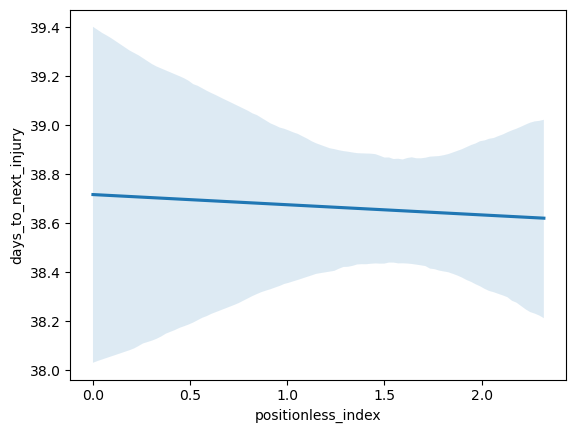

In [30]:
import seaborn as sns

df_has_injury = df.dropna(subset=["days_to_next_injury"])
sns.regplot(x=df_has_injury['positionless_index'], y=df_has_injury['days_to_next_injury'], scatter=False)
del df_has_injury

In [31]:
df = df.sort_values(
    ["personId", "gameDateTimeEst_player"]
).reset_index(drop=True)

# Calculating rolling statistics since stats from the game itself may be
# contaminated by player getting injured during that game
# Over last 3 and 7 games

rolling_map = {
    'numMinutes_player': 'minutes',
    'points_player': 'points',
    'assists_player': 'assists',
    'reboundsTotal_player': 'rebounds',
    'steals_player': 'steals',
    'blocks_player': 'blocks',
    'turnovers_player': 'turnovers',
    'fieldGoalsMade_player': 'field_goals_made',
    'fieldGoalsAttempted_player': 'field_goals_attempted',
    'threePointersMade_player': 'three_pointers_made',
    'threePointersAttempted_player': 'three_pointers_attempted',
    'threePointersPercentage_player': 'three_point_percent',
    'points_per36': 'points_per36',
    'assists_per36': 'assists_per36',
    'blocks_per36': 'blocks_per36',
    'steals_per36': 'steals_per36',
    '3pRelativePercent': '3p_relative_percent',
    'ftRelativePercent': 'ft_relative_percent',
    'USG': 'USG',
}
cols = list(rolling_map.keys())

shifted = df.groupby("personId")[cols].shift(1)

rolling3 = (
    shifted.groupby(df["personId"])
     .rolling(3, min_periods=1)
     .mean()
     .reset_index(level=0, drop=True)
)

rolling7 = (
    shifted.groupby(df["personId"])
     .rolling(7, min_periods=1)
     .mean()
     .reset_index(level=0, drop=True)
)
rolling3.columns = [f"rolling_3g_{rolling_map[c]}" for c in rolling3.columns]
rolling7.columns = [f"rolling_7g_{rolling_map[c]}" for c in rolling7.columns]

df = pd.concat([df, rolling3, rolling7], axis=1)
del rolling3, rolling7, shifted

# Days rest (and back-to-back status) since last game
df["days_rest"] = (
    df.groupby("personId")["gameDateTimeEst_player"]
      .diff()
      .dt.days
)
df["back_to_back"] = (
    df["days_rest"] <= 1
).astype(int)

df["game_played"] = 1

df["games_last_14d"] = (
    df.sort_values(["personId", "gameDateTimeEst_player"])
      .groupby("personId")["game_played"]
      .apply(lambda x: x.shift(1).rolling(14, min_periods=1).sum())
      .reset_index(level=0, drop=True)
)
df = df.drop(columns=['game_played'])

df.to_parquet('../data/Player-Games with Injuries.parquet')